# Monte Carlo: estimating things you cannot compute

Three problems that look unrelated:

- What is $\pi$?
- What is $P(3 \le X \le 6)$ when $X \sim \text{Normal}(1, 10)$?
- You spin a four-wedge spinner ten times. What is the chance your total is negative?

**They are the same problem.** Each answer is an *expectation*, an expectation is an *average*, and
you can estimate any average by sampling and taking the mean. That is the whole of Monte Carlo. The
rest is knowing how much to trust the number you get.

This notebook does all three by hand, then measures the one thing that decides whether the method is
usable: **how fast the error shrinks.**

## Set the seed, and print it

Everything below is random. If the seed is not fixed, every number in this notebook is different
tomorrow and none of the prose can be trusted — which is exactly what was wrong with the versions
these examples came from.

Printing it matters as much as setting it: a seed in a variable you cannot see is not reproducible
for the reader.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

SEED = 20260904
print(f"seed = {SEED}")

seed = 20260904


## 1. Pi, by throwing darts

Draw the square from $-1$ to $1$ in both directions, and the circle of radius 1 inside it.

- area of the square = $2 \times 2 = 4$
- area of the circle = $\pi r^2 = \pi$

So the fraction of the square covered by the circle is $\pi/4$. Throw darts uniformly at the square,
count the fraction landing inside the circle, multiply by 4.

**Predict before running:** with 200,000 darts, how many decimal places of $\pi$ do you expect to get
right? Write the number down.

In [2]:
rng = np.random.default_rng(SEED)
n = 200_000

xs = rng.uniform(-1, 1, n)
ys = rng.uniform(-1, 1, n)

print(f"threw {n:,} darts")
print(f"first three: ({xs[0]:+.3f}, {ys[0]:+.3f})  ({xs[1]:+.3f}, {ys[1]:+.3f})  ({xs[2]:+.3f}, {ys[2]:+.3f})")

threw 200,000 darts
first three: (+0.712, -0.292)  (+0.733, -0.020)  (-0.568, -0.901)


A dart is inside the circle when $x^2 + y^2 \le 1$. That single comparison is the entire model.

In [3]:
inside = xs**2 + ys**2 <= 1.0

print(f"inside the circle : {inside.sum():,} of {n:,}")
print(f"fraction          : {inside.mean():.6f}")

inside the circle : 156,942 of 200,000
fraction          : 0.784710


The fraction should be near $\pi/4 \approx 0.785$. Multiply by 4 to get the estimate, and compare
against the real thing.

In [4]:
import math

pi_hat = 4 * inside.mean()
print(f"estimate : {pi_hat:.6f}")
print(f"true     : {math.pi:.6f}")
print(f"error    : {abs(pi_hat - math.pi):.6f}")

estimate : 3.138840
true     : 3.141593
error    : 0.002753


Now look at it. Plotting all 200,000 points is slow and tells you nothing extra, so plot the first
3,000 — enough to see the shape, which is the only reason to draw it.

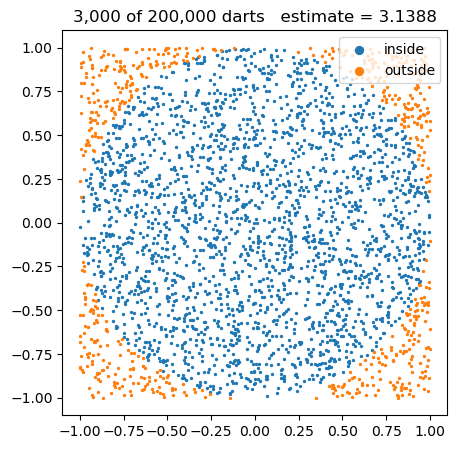

In [5]:
show = 3000
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(xs[:show][inside[:show]], ys[:show][inside[:show]], s=2, label="inside")
ax.scatter(xs[:show][~inside[:show]], ys[:show][~inside[:show]], s=2, label="outside")
ax.set_aspect("equal")
ax.set_title(f"{show:,} of {n:,} darts   estimate = {pi_hat:.4f}")
ax.legend(loc="upper right", markerscale=4)
plt.show()

## The law that decides whether this is worth doing

The estimate is a proportion, so its standard error is $\sqrt{p(1-p)/n}$ — it shrinks like
$1/\sqrt{n}$, not like $1/n$.

That is the crucial and slightly depressing fact about Monte Carlo. **A hundredfold more samples buys
one more correct digit.**

**Predict:** you used 200,000 darts. How many would you need for six correct decimal places?

In [6]:
p = inside.mean()
for size in (10**3, 10**4, 10**5, 10**6, 10**8, 10**10):
    se_pi = 4 * math.sqrt(p * (1 - p) / size)
    print(f"n = {size:>14,}   standard error on pi ~ {se_pi:.2e}")

n =          1,000   standard error on pi ~ 5.20e-02
n =         10,000   standard error on pi ~ 1.64e-02
n =        100,000   standard error on pi ~ 5.20e-03
n =      1,000,000   standard error on pi ~ 1.64e-03
n =    100,000,000   standard error on pi ~ 1.64e-04
n = 10,000,000,000   standard error on pi ~ 1.64e-05


Six decimal places needs on the order of $10^{12}$ darts. This is why nobody computes $\pi$ this way,
and why Monte Carlo is nonetheless indispensable: in a problem with twenty uncertain quantities,
every alternative is far worse, and $1/\sqrt{n}$ does not care how many dimensions there are.

## 2. A probability nobody wants to integrate by hand

$X \sim \text{Normal}(\mu = 1, \sigma = 10)$. What is $P(3 \le X \le 6)$?

That is the integral of the normal density between 3 and 6, and the normal has no elementary
antiderivative. Sampling avoids the integral entirely: draw from the distribution, count how many
land in the interval.

**Predict:** the interval is 3 units wide, sitting a little right of the mean, on a distribution with
a standard deviation of 10. Roughly what fraction lands inside — 1%, 10%, or 30%?

In [7]:
rng = np.random.default_rng(SEED)
sims = rng.normal(loc=1.0, scale=10.0, size=200_000)

in_band = (sims >= 3) & (sims <= 6)
p_hat = in_band.mean()

print(f"samples in [3, 6] : {in_band.sum():,} of {len(sims):,}")
print(f"estimate          : {p_hat:.6f}")

samples in [3, 6] : 22,654 of 200,000
estimate          : 0.113270


This one has an exact answer, so the estimate can be checked rather than trusted. `math.erf` gives the
normal CDF without needing SciPy.

In [8]:
def_cdf = lambda x: 0.5 * (1.0 + math.erf((x - 1.0) / (10.0 * math.sqrt(2.0))))
exact_band = def_cdf(6) - def_cdf(3)
se_band = math.sqrt(p_hat * (1 - p_hat) / len(sims))

print(f"estimate : {p_hat:.6f}")
print(f"exact    : {exact_band:.6f}")
print(f"error    : {abs(p_hat - exact_band):.6f}   ({abs(p_hat-exact_band)/se_band:.2f} standard errors)")

estimate : 0.113270
exact    : 0.112203
error    : 0.001067   (1.51 standard errors)


Within a couple of standard errors, which is what "correct" means for a stochastic method. Draw the
sample against the true density to see what was actually measured.

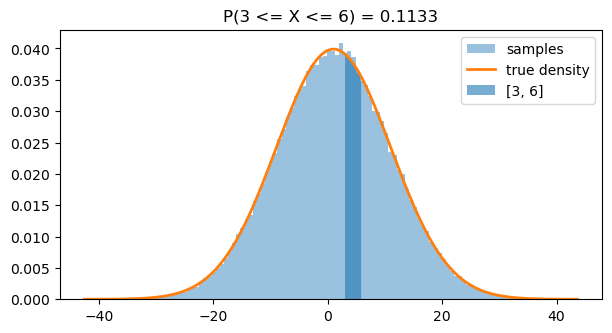

In [9]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(sims, bins=120, density=True, alpha=0.45, label="samples")
grid = np.linspace(sims.min(), sims.max(), 400)
dens = (1 / (10 * np.sqrt(2 * np.pi))) * np.exp(-((grid - 1) ** 2) / (2 * 10 ** 2))
ax.plot(grid, dens, lw=2, label="true density")
band = (grid >= 3) & (grid <= 6)
ax.fill_between(grid[band], dens[band], alpha=0.6, label="[3, 6]")
ax.set_title(f"P(3 <= X <= 6) = {p_hat:.4f}")
ax.legend()
plt.show()

## 3. The spinner game, where the exact answer is computable

A spinner has four equally likely wedges: **+1, +1, −1, +2**. You spin it ten times and add up the
results. You lose if the total is negative.

Three of the four wedges are positive and the average spin is $+0.75$, so ten spins average $+7.5$.
Losing needs a bad run.

**Predict:** is the chance of losing closer to 1 in 10, 1 in 100, or 1 in 1,000?

In [10]:
rng = np.random.default_rng(SEED)
wedges = np.array([1, 1, -1, 2])
spins, games = 10, 200_000

draws = rng.choice(wedges, size=(games, spins), replace=True)
totals = draws.sum(axis=1)
lost = totals < 0

print(f"played {games:,} games of {spins} spins")
print(f"first game spins  : {draws[0]}  total {totals[0]:+d}")
print(f"games lost        : {lost.sum():,}")
print(f"estimated P(lose) : {lost.mean():.6f}")

played 200,000 games of 10 spins
first game spins  : [-1  2 -1  2  2  1  2  2 -1 -1]  total +7
games lost        : 2,604
estimated P(lose) : 0.013020


### The exact answer, so there is something true to converge to

Ten spins of four outcomes is about a million paths — but the distribution over *totals* has only a
few dozen values, so it can be built exactly by convolution: start with "total 0 with probability 1",
and fold in one spin at a time.

This matters more than it looks. The version of this example these notebooks came from plotted a red
line labelled **"True Probability"** that was in fact the final Monte Carlo estimate. It showed the
estimate converging to itself — which is guaranteed, and therefore says nothing.

In [11]:
dist = {0: 1.0}
for _ in range(spins):
    nxt = {}
    for total, prob in dist.items():
        for w in wedges:
            nxt[total + int(w)] = nxt.get(total + int(w), 0.0) + prob / len(wedges)
    dist = nxt

exact_lose = sum(p for total, p in dist.items() if total < 0)

print(f"distinct totals reachable : {len(dist)}")
print(f"total probability mass    : {sum(dist.values()):.10f}")
print(f"exact P(lose)             : {exact_lose:.6f}")

distinct totals reachable : 30
total probability mass    : 1.0000000000
exact P(lose)             : 0.013119


Now plot the running estimate against the **real** exact value. Convergence to a line computed a
different way is evidence; convergence to yourself is not.

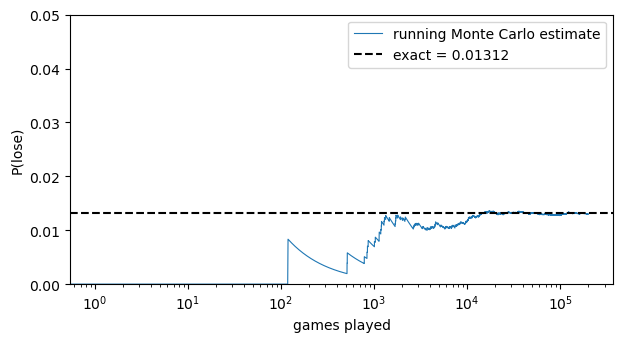

In [12]:
running = np.cumsum(lost) / np.arange(1, games + 1)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(running, lw=0.8, label="running Monte Carlo estimate")
ax.axhline(exact_lose, color="black", ls="--", lw=1.5, label=f"exact = {exact_lose:.5f}")
ax.set_xscale("log")
ax.set_ylim(0, 0.05)
ax.set_xlabel("games played")
ax.set_ylabel("P(lose)")
ax.legend()
plt.show()

The wobble at the left is the estimate with too few games; it settles as $1/\sqrt{n}$ predicts. Check
that the exact value actually lies inside the confidence interval, rather than eyeballing the plot.

In [13]:
p_lose = lost.mean()
se_lose = math.sqrt(p_lose * (1 - p_lose) / games)
lo95, hi95 = p_lose - 1.96 * se_lose, p_lose + 1.96 * se_lose

print(f"estimate : {p_lose:.6f}")
print(f"95% CI   : [{lo95:.6f}, {hi95:.6f}]")
print(f"exact    : {exact_lose:.6f}")
assert lo95 <= exact_lose <= hi95, "exact value falls outside the confidence interval"
print("\nexact value lies inside the interval, as it should about 95% of the time")

estimate : 0.013020
95% CI   : [0.012523, 0.013517]
exact    : 0.013119

exact value lies inside the interval, as it should about 95% of the time


---

# Now the streamlined version

All three estimators are the same three lines — sample, test a condition, take the mean — so they are
worth folding into one place now that you have written each out. `orteach.montecarlo` holds them,
along with the exact spinner calculation.

Every function takes an explicit `seed`, for the reason the top of this notebook gives.

In [14]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join("..", "..", "src")))
from orteach import montecarlo as omc

pkg_pi     = omc.estimate_pi(200_000, seed=SEED)
pkg_band   = omc.estimate_normal_interval(3, 6, mu=1.0, sigma=10.0, n=200_000, seed=SEED)
pkg_spin   = omc.simulate_spinner(200_000, seed=SEED)
pkg_exact  = omc.exact_spinner_probability()

print(f"{'':22} {'estimate':>12} {'std error':>12}")
print(f"{'pi/4':22} {pkg_pi.estimate:12.6f} {pkg_pi.std_error:12.2e}")
print(f"{'P(3<=X<=6)':22} {pkg_band.estimate:12.6f} {pkg_band.std_error:12.2e}")
print(f"{'P(spinner total<0)':22} {pkg_spin.estimate:12.6f} {pkg_spin.std_error:12.2e}")
print(f"{'  exact, for comparison':22} {pkg_exact:12.6f}")

                           estimate    std error
pi/4                       0.784710     9.19e-04
P(3<=X<=6)                 0.113270     7.09e-04
P(spinner total<0)         0.013020     2.53e-04
  exact, for comparison     0.013119


## The agreement assertion

The package and this notebook now compute the same three things twice, deliberately. The check below
is what makes that safe: same seed, same sample size, so the answers must match **exactly**, not
approximately. Any difference means the two are not running the same procedure.

In [15]:
checks = [
    ("pi/4",              inside.mean(), pkg_pi.estimate),
    ("P(3 <= X <= 6)",    p_hat,         pkg_band.estimate),
    ("P(spinner < 0)",    p_lose,        pkg_spin.estimate),
    ("exact P(spinner)",  exact_lose,    pkg_exact),
]

worst = 0.0
for name, hand, packaged in checks:
    rel = abs(packaged - hand) / max(abs(hand), 1e-12)
    worst = max(worst, rel)
    print(f"{name:20} hand {hand:12.8f}   package {packaged:12.8f}   rel {rel:.2e}")

assert worst < 1e-9, f"notebook and package disagree by {worst:.2e}"
print(f"\nnotebook and package agree to {worst:.1e}")

pi/4                 hand   0.78471000   package   0.78471000   rel 0.00e+00
P(3 <= X <= 6)       hand   0.11327000   package   0.11327000   rel 0.00e+00
P(spinner < 0)       hand   0.01302000   package   0.01302000   rel 0.00e+00
exact P(spinner)     hand   0.01311874   package   0.01311874   rel 0.00e+00

notebook and package agree to 0.0e+00


---

## Where to take this next

- Change `SEED` and re-run. Every number moves; every conclusion stays. That distinction is the point.
- Drop `games` to 1,000 and look at the convergence plot again. How badly can 1,000 games mislead you?
- The spinner's exact answer was computable because the state space was small. Add a wedge worth
  $+100$ and the totals spread out — at what point does exact convolution stop being practical, and
  what do you do then?